In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.clean import load_data, clean_data
from src.features import engineer_features

df_raw = load_data('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = clean_data(df_raw)
df = engineer_features(df)
print(df.shape)
df.head()

(7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,NumServices,TenureBucket
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,2,new
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,55.573529,4,established
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,4,new
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,4,established
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,2,new


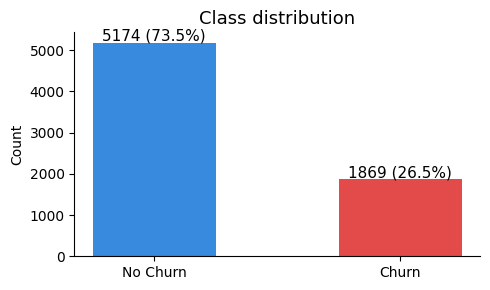

In [8]:
# Cell 2 — Class imbalance (most important EDA for this project)
fig, ax = plt.subplots(figsize=(5, 3))
counts = df['Churn'].value_counts()
ax.bar(['No Churn', 'Churn'], counts.values,color=['#378ADD', '#E24B4A'], width=0.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f'{v} ({v/len(df)*100:.1f}%)',ha='center', fontsize=11)
ax.set_title('Class distribution', fontsize=13)
ax.set_ylabel('Count')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
# ~73% No Churn, ~27% Churn — confirms we need SMOTE or class_weight

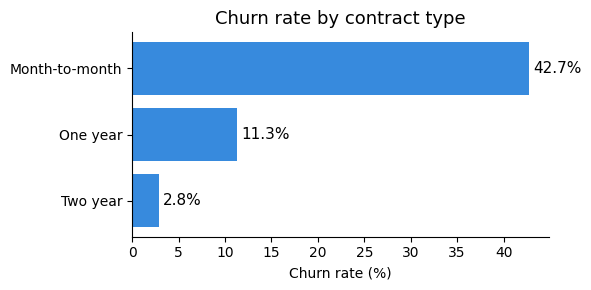

In [9]:
# Cell 3 — Churn rate by contract type (most predictive feature)
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values()
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(contract_churn.index, contract_churn.values * 100,color='#378ADD')
ax.set_xlabel('Churn rate (%)')
ax.set_title('Churn rate by contract type', fontsize=13)
for bar, val in zip(bars, contract_churn.values):
    ax.text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
# Month-to-month contracts churn ~43% vs Two year ~3%

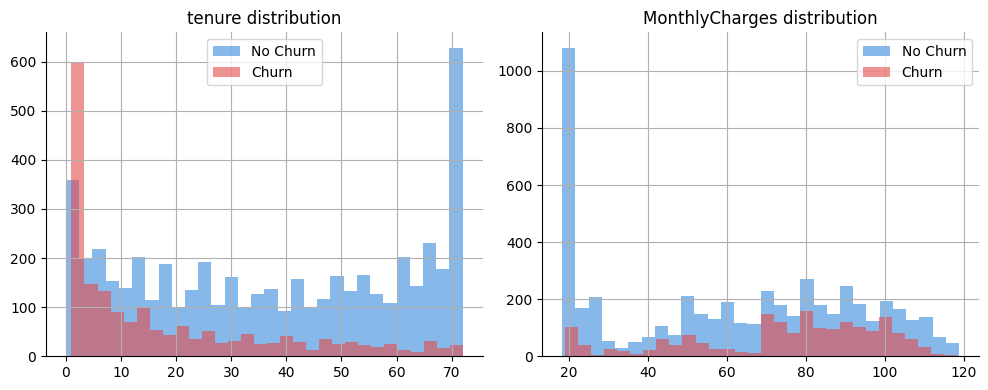

In [11]:
# Cell 4 — Tenure vs churn (numeric distribution)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges']):
    df[df['Churn']==0][col].hist(ax=ax, alpha=0.6, label='No Churn',color='#378ADD', bins=30)
    df[df['Churn']==1][col].hist(ax=ax, alpha=0.6, label='Churn',color='#E24B4A', bins=30)
    ax.set_title(f'{col} distribution', fontsize=12)
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
# Low tenure = high churn. High monthly charges = higher churn risk.

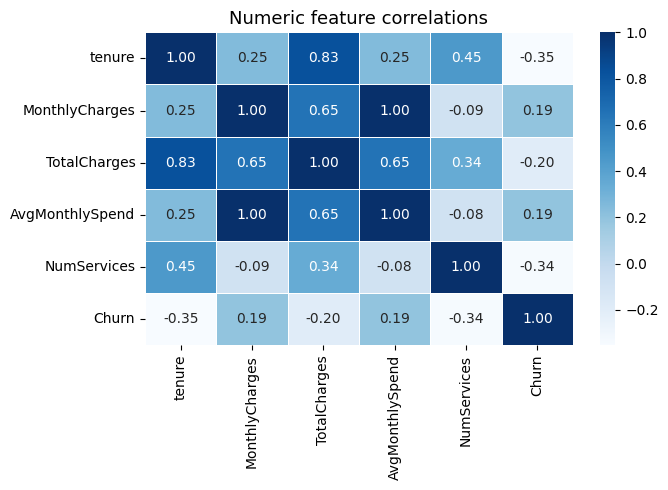

In [12]:
# Cell 5 — Correlation heatmap (numeric features only)
num_df = df[['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend','NumServices','Churn']]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f',
            cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Numeric feature correlations', fontsize=13)
plt.tight_layout()
plt.show()
# tenure strongly negatively correlated with Churn (−0.35)
# MonthlyCharges positively correlated (+0.19)

In [13]:
# Cell 6 — Missing values check
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values:\n", missing if len(missing) > 0 else "None — clean dataset!")
print("\nData types:\n", df.dtypes)
print("\nShape:", df.shape)

Missing values:
 None — clean dataset!

Data types:
 gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                  int64
AvgMonthlySpend      float64
NumServices            int64
TenureBucket        category
dtype: object

Shape: (7043, 23)
